In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [2]:
from src.tracking.track import Track
from src.tracking.track_manager import TrackManager
from src.tracking.kalman_filter import KalmanFilter
from src.evaluation import metrics, plotting
from src.scenarios import (
    truth_generator,
)  # generate truth measurements based on config

In [3]:
from src.models import (
    measurement_models,
    motion_models,
) 

In [4]:
from configs.multi_track_ss_baseline import (
    R,
    Q,
    P0,
    truth_data,
    id_miss_index,
    dt,
    Q,
    measurement_noise,
    ss_baseline_seed,
)  # everything here comes just from baseline

In [5]:
H = measurement_models.H
F = motion_models.F

In [6]:
def angle_between(v1, v2):
    v1_u = v1 / np.linalg.norm(v1)
    v2_u = v2 / np.linalg.norm(v2)
    dot_product = np.dot(v1_u, v2_u)
    angle_rad = np.arccos(np.clip(dot_product, -1.0, 1.0))

    return np.degrees(angle_rad)

In [7]:
ss_baseline_seed()
(truth_states, truth_positions, truth_velocities, truth_times, truth_exists, scans) = (
    truth_generator.generate_truth(
        100, truth_data, P0, id_miss_index, R, dt, measurement_noise
    )
)

In [8]:
# places all of the k-1 tracks into kf objects and track objects.
trax = [
    Track(
        track["id"],
        KalmanFilter(
            F=F,
            H=H,
            R=R,
            Q=Q,
            x_hat_km1_km1=track["x"],
            P_km1_km1=track["P"],
        ),
    )
    for track in truth_data
]
tracker = TrackManager(trax, 5.991)  # all tracks are stored into the trackmanager
# truth_states - For each track id x_i_t = [p_x, p_y, v_x, v_y] for i = {1,2,3,4,5} and t = {k-1, k, k+1, ... k+99}
# truth_positions - For each track id x_i_t = [p_x, p_y] for i = {1,2,3,4,5} and t = {k-1, k, k+1, ... k+99}
# truth_velocities - For each track id x_i_t = [v_x, v_y] for i = {1,2,3,4,5} and t = {k-1, k, k+1, ... k+99}
# truth_times - delta = 1.5, t = {delta*i, delta*i+1,...} for i = {0,1, 2, ... 100}
# truth_exists - truth_exists = {1 if track_i should have a hit at t = k, 0 otherwise}
# scans - {z_1, z_2, z_3, ...} for z_i in F@x + v(0, R) for timestep k_j , j = {k, k+1, ...}
tracker.scan_log[0] = {
    "time": truth_times[0],
    "num_measurements": 0,
    "num_tracks": len(tracker.tracks),
}

for index, measurements in scans.items():
    tracker.scan_log[index] = {
        "time": truth_times[index],
        "num_measurements": len(measurements),
        "num_tracks": len(tracker.tracks),
    }
    tracker.predict_all()
    assignments, unassigned_tracks, unassigned_measurements, _ = tracker.gnn_associate(
        measurements, index
    )

    assignment_map = {a["track_id"]: a["measurement"] for a in assignments}
    unassigned_track_ids = {t["track_id"] for t in unassigned_tracks}
    tracks_to_delete = []

    tracker.pred_log[index] = {}
    for trk in tracker.tracks:
        tracker.pred_log[index][trk.track_id] = [trk.kf.x_hat_k_km1, trk.kf.P_k_km1]

        if trk.track_id in assignment_map:
            z_k = assignment_map[trk.track_id]  # Get measurement from ass map

            trk.update(z_k)  # use measurement / prediction to update
            if trk.track_id in truth_states.keys():
                tracker.log_error(trk, truth_states[trk.track_id][index])
            if trk.tentative:  # if its a tentative track increase hit count by 1
                trk.hit_count += 1
                if trk.hit_count >= 3:  # promote track if hit count >= 2
                    trk.promote_track()
                    print(
                        f"tentative Track ID: {trk.track_id} Promoted! Hit Count: {trk.hit_count}"
                    )
            print(f"Track {trk.track_id} Detected!")

        elif (
            trk.track_id in unassigned_track_ids
        ):  # if this track id is unassigned then mark as a miss and coast
            # predication from k|k-1 -> k|k
            trk.miss()
            trk.coast()
            print(f"Track {trk.track_id} Missed Detection!")

        if (
            trk.tentative and trk.missed_count >= 2
        ):  # delete a tentative track with missed count >= 2
            print(
                f"tentative Track ID: {trk.track_id} Deleted, Missed Count: {trk.missed_count} >= 2"
            )
            tracks_to_delete.append(trk)

        elif (not trk.tentative) and trk.missed_count >= 5:
            # delete a confirmed track with miss count > = 3
            print(
                f"Confirmed Track ID: {trk.track_id} Deleted, Missed Count: {trk.missed_count} >= 3"
            )
            tracks_to_delete.append(trk)

    for trk in tracks_to_delete:  # accutally delete the tracks from the list.
        tracker.delete_track(trk)

    for meas in unassigned_measurements:
        # For each unassigned measurement create a tentative track
        ten_track_id = tracker.tentative_track(
            meas["measurement"],
            tracker.get_new_track_id(),
            F,
            H,
            Q,
            R,
        )
        print(f"tentative Track ID: {ten_track_id} Created!")

Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Missed Detection!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Tr

In [9]:
rmse, _, n = metrics.position_rmse_from_truth_and_predlog(
    truth_states, tracker.pred_log
)
per_track_rmse = metrics.position_rmse_per_track_from_truth_and_predlog(
    truth_states, tracker.pred_log
)
coverage = metrics.track_coverage_from_truth_and_predlog(truth_states, tracker.pred_log)
print("Total Tracks:", max([x.track_id for x in tracker.tracks]))
print("Overall RMSE:", rmse)
print("Per-track RMSE:", per_track_rmse)
print("Coverage:", coverage)
print("Matched samples:", n, "of", int(n / coverage))

Total Tracks: 6
Overall RMSE: 1.8598922043067196
Per-track RMSE: {1: 2.649517024176919, 2: 1.7197770586511985, 3: 1.641983708298525, 4: 1.5196953985760118, 5: 1.6553325456049208}
Coverage: 0.976
Matched samples: 488 of 500


In [10]:
metrics.nis_metrics(tracker, truth_data) # NIS BASED

Track_1 NIS: 0.6314046124563485
Track_2 NIS: 0.8526896560910443
Track_3 NIS: 0.9323267824390494
Track_4 NIS: 0.8051115866160117
Track_5 NIS: 0.9647876921987824
------

Overall NIS: 0.8471902031312947


In [11]:
metrics.nees_metrics(tracker, truth_data)

Track_1 NEES: 2.4057977156809165
Track_2 NEES: 3.2783959084061296
Track_3 NEES: 2.4872383844244896
Track_4 NEES: 2.4738964993828607
Track_5 NEES: 2.507231456853457
------

Overall NEES: 2.641347272566298


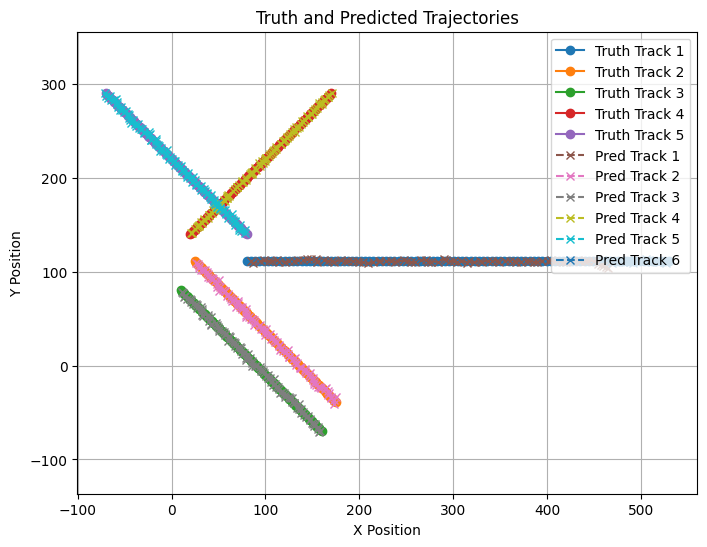

In [12]:
plotting.plot_tracks(truth_positions, tracker)

In [13]:
tracker.update_log

{1: [3.292241315532145,
  5.206936075267564,
  1.8072254874337044,
  0.4544385836170315,
  0.47945153868287943,
  2.123473535840735,
  3.9636129946931113,
  0.8892093438726503,
  3.1670648034543,
  1.4778868423613445,
  4.513979250277083,
  1.4757481531436953,
  7.657212198221733,
  3.811668147443884,
  0.8986048186474467,
  1.3175332951331555,
  3.6039456543566484,
  2.318083290673627,
  0.990585707213047,
  1.6593959346401,
  3.3282363933499397,
  4.899315930267661,
  7.33106438050537,
  5.555299146907051,
  2.9605760195331596,
  5.047522283036717,
  0.8585920610043227,
  1.3172761372921975,
  4.001238043944778,
  3.3558643695961963,
  3.3544209853046527,
  1.9085553269676643,
  0.575368166343943,
  2.7188718243452374,
  3.486828200894133,
  1.5789437515408862,
  1.5596999678981234,
  1.3376423532648793,
  8.129900276403117,
  3.71749474187324,
  2.583362422244323,
  1.4148905747712424,
  1.4083319614767937,
  4.375494133637624,
  3.5651569242971917,
  1.8580572452260717,
  1.9662545

READ ABOUT MOTA / MOTP